Found 1514 images belonging to 7 classes.
Found 373 images belonging to 7 classes.


C:\Users\VISHAL JAIN\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 200s 4s/step - accuracy: 0.3229 - loss: 1.8595 - val_accuracy: 0.2359 - val_loss: 1.9481 - learning_rate: 1.0000e-04
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 154s 3s/step - accuracy: 0.4719 - loss: 1.3001 - val_accuracy: 0.1984 - val_loss: 1.9118 - learning_rate: 1.0000e-04
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 161s 3s/step - accuracy: 0.5077 - loss: 1.2015 - val_accuracy: 0.1877 - val_loss: 1.9496 - learning_rate: 1.0000e-04
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 155s 3s/step - accuracy: 0.5566 - loss: 1.0375 - val_accuracy: 0.1769 - val_loss: 2.0858 - learning_rate: 1.0000e-04
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5659 - loss: 1.0079
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
48/48 ━━━━━━━━━━━━━━━━━━━━ 154s 3s/step - accuracy: 0.5659 - loss: 1.0087 - val_accuracy: 0.1877 - val_loss: 2.1233 - learning_rate: 1.0000e-04
Epoch 6/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 154s 3s/step - accuracy: 0.5618 - loss

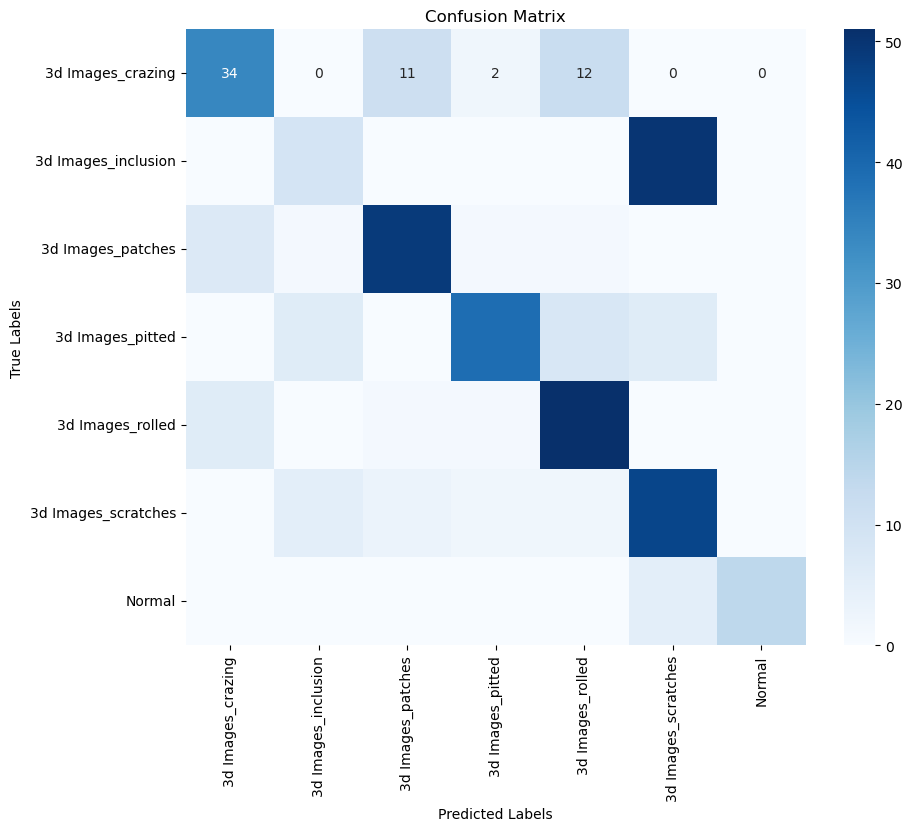

Classification Report:
                      precision    recall  f1-score   support

  3d Images_crazing       0.72      0.58      0.64        59
3d Images_inclusion       0.43      0.15      0.23        59
  3d Images_patches       0.77      0.83      0.80        59
   3d Images_pitted       0.87      0.66      0.75        59
   3d Images_rolled       0.69      0.86      0.77        59
3d Images_scratches       0.44      0.80      0.56        59
             Normal       1.00      0.74      0.85        19

           accuracy                           0.65       373
          macro avg       0.70      0.66      0.66       373
       weighted avg       0.67      0.65      0.64       373

AUC for class 3d Images_crazing: 0.9549
AUC for class 3d Images_inclusion: 0.9234
AUC for class 3d Images_patches: 0.9780
AUC for class 3d Images_pitted: 0.9584
AUC for class 3d Images_rolled: 0.9609
AUC for class 3d Images_scratches: 0.9075
AUC for class Normal: 0.9999

🔥 Overall Macro-Averaged AUC: 

In [ ]:
# Import Libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# Set Image Size & Batch Size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.2,
    zoom_range=0.4,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    validation_split=0.2
)

# Load Train & Validation Data
train_generator = train_datagen.flow_from_directory(
     r"C:\Users\VISHAL JAIN\Downloads\Vips Folder\Practicum\Metal Defect\metal defect-20250313T163927Z-001\metal defect",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
     r"C:\Users\Shreja Garg\Downloads\Vips Folder\Practicum\Metal Defect\metal defect-20250313T163927Z-001\metal defect",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Compute Class Weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))

# Load Pretrained ResNet50 (Fine-Tuning)
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers[:-10]:
    layer.trainable = False

# Add Custom Layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.3)(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
output_layer = Dense(train_generator.num_classes, activation="softmax")(x)

# Create Model
model = Model(inputs=base_model.input, outputs=output_layer)

# Compile Model
model.compile(optimizer=AdamW(learning_rate=0.0001), loss="categorical_crossentropy", metrics=["accuracy"])

# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, verbose=1, min_lr=1e-7),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
]

# Train Model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# Save Model
model.save("high_accuracy_model.keras")

# Evaluate Model
val_loss, val_acc = model.evaluate(validation_generator)
print(f"🔥 Final Validation Accuracy: {val_acc:.4f} 🔥")

# ======== Performance Evaluation ========

# Get True Labels and Predictions
y_true = []
y_pred = []
y_pred_proba = []

for batch in validation_generator:
    images, labels = batch
    preds = model.predict(images)

    y_true.extend(np.argmax(labels, axis=1))  # True labels
    y_pred.extend(np.argmax(preds, axis=1))  # Predicted labels
    y_pred_proba.extend(preds)  # Predicted probabilities

    if len(y_true) >= validation_generator.samples:
        break

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_pred_proba = np.array(y_pred_proba)

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=validation_generator.class_indices, yticklabels=validation_generator.class_indices)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=validation_generator.class_indices))

# Compute AUC for each class
auc_scores = []
for i in range(y_pred_proba.shape[1]):
    auc = roc_auc_score((y_true == i).astype(int), y_pred_proba[:, i])
    auc_scores.append(auc)

# Print AUC Scores
for class_name, auc in zip(validation_generator.class_indices, auc_scores):
    print(f"AUC for class {class_name}: {auc:.4f}")

# Overall AUC (macro-average)
macro_auc = np.mean(auc_scores)
print(f"\n🔥 Overall Macro-Averaged AUC: {macro_auc:.4f} 🔥")


Found 183 images belonging to 7 classes.


C:\Users\VISHAL JAIN\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 556ms/step - accuracy: 0.8376 - loss: 0.4831
🔥 Test Accuracy: 0.8907 🔥
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 594ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 656ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 586ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 742ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 608ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 785ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 652ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 731ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 714ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 715ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 611ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 608ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 560ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 624ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 663ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 555ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 630ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 590ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 574ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 577ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 583ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 605ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 609ms/step
1

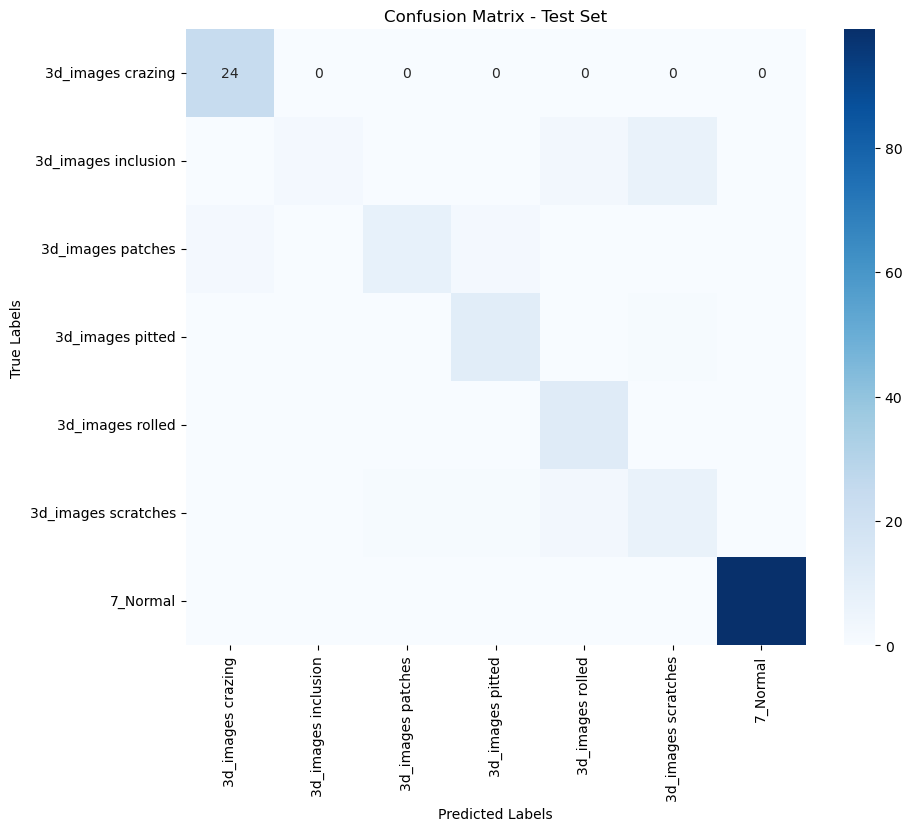

Classification Report:
                     precision    recall  f1-score   support

  3d_images crazing       0.92      1.00      0.96        24
3d_images inclusion       1.00      0.17      0.29        12
  3d_images patches       0.89      0.67      0.76        12
   3d_images pitted       0.79      0.92      0.85        12
   3d_images rolled       0.67      1.00      0.80        12
3d_images scratches       0.47      0.58      0.52        12
           7_Normal       1.00      1.00      1.00        99

           accuracy                           0.89       183
          macro avg       0.82      0.76      0.74       183
       weighted avg       0.91      0.89      0.88       183

AUC for class 3d_images crazing: 0.9979
AUC for class 3d_images inclusion: 0.9639
AUC for class 3d_images patches: 0.9829
AUC for class 3d_images pitted: 0.9942
AUC for class 3d_images rolled: 0.9971
AUC for class 3d_images scratches: 0.7963
AUC for class 7_Normal: 1.0000

🔥 Overall Macro-Averaged AUC:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Define Image Parameters
IMG_SIZE = (224, 224)  # Adjust as needed
BATCH_SIZE = 7

# Define Test Directory
TEST_DIR = r"C:\Users\VISHAL JAIN\Downloads\Vips Folder\Practicum\Metal Defect\Testt-20250406T105607Z-001\Testt"

# Load Test Data
test_datagen = ImageDataGenerator(rescale=1.0/255)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # Keep order for evaluation
)

# Evaluate Model on Test Set
test_loss, test_acc = model.evaluate(test_generator)
print(f"🔥 Test Accuracy: {test_acc:.4f} 🔥")

# Get True Labels and Predictions
y_true = []
y_pred = []
y_pred_proba = []

for batch in test_generator:
    images, labels = batch
    preds = model.predict(images)

    y_true.extend(np.argmax(labels, axis=1))  # True labels
    y_pred.extend(np.argmax(preds, axis=1))  # Predicted labels
    y_pred_proba.extend(preds)  # Predicted probabilities

    if len(y_true) >= test_generator.samples:
        break

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_pred_proba = np.array(y_pred_proba)

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - Test Set")
plt.show()

# Classification Report
target_names = list(test_generator.class_indices.keys())
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=target_names))

# Compute AUC for each class
auc_scores = []
for i in range(y_pred_proba.shape[1]):
    auc = roc_auc_score((y_true == i).astype(int), y_pred_proba[:, i])
    auc_scores.append(auc)

# Print AUC Scores
for class_name, auc in zip(target_names, auc_scores):
    print(f"AUC for class {class_name}: {auc:.4f}")

# Overall AUC (macro-average)
macro_auc = np.mean(auc_scores)
print(f"\n🔥 Overall Macro-Averaged AUC: {macro_auc:.4f} 🔥")


Found 1406 images belonging to 7 classes.
Found 349 images belonging to 7 classes.


C:\Users\VISHAL JAIN\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 209s 4s/step - accuracy: 0.4295 - loss: 1.4857 - val_accuracy: 0.1576 - val_loss: 2.0611 - learning_rate: 1.0000e-04
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 183s 4s/step - accuracy: 0.6790 - loss: 0.8439 - val_accuracy: 0.1977 - val_loss: 2.0680 - learning_rate: 1.0000e-04
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 161s 4s/step - accuracy: 0.7045 - loss: 0.7408 - val_accuracy: 0.2407 - val_loss: 2.0842 - learning_rate: 1.0000e-04
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7177 - loss: 0.7213
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
44/44 ━━━━━━━━━━━━━━━━━━━━ 158s 4s/step - accuracy: 0.7181 - loss: 0.7205 - val_accuracy: 0.2980 - val_loss: 2.1112 - learning_rate: 1.0000e-04
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 160s 4s/step - accuracy: 0.7402 - loss: 0.6937 - val_accuracy: 0.2464 - val_loss: 2.0385 - learning_rate: 3.0000e-05
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 160s 4s/step - accuracy: 0.7920 - loss

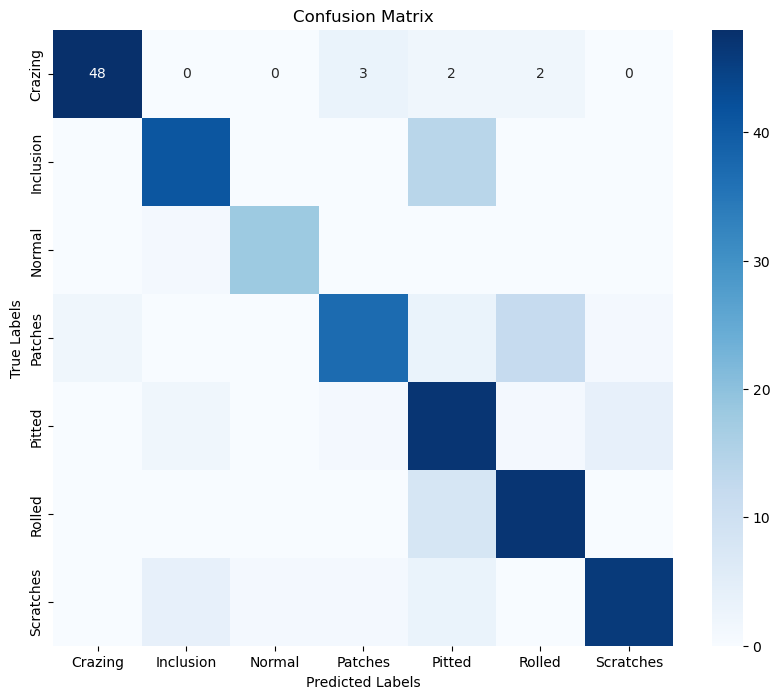

Classification Report:
               precision    recall  f1-score   support

     Crazing       0.96      0.87      0.91        55
   Inclusion       0.85      0.75      0.80        55
      Normal       0.95      0.95      0.95        19
     Patches       0.88      0.67      0.76        55
      Pitted       0.61      0.85      0.71        55
      Rolled       0.76      0.85      0.80        55
   Scratches       0.90      0.84      0.87        55

    accuracy                           0.81       349
   macro avg       0.84      0.83      0.83       349
weighted avg       0.83      0.81      0.82       349

AUC for class Crazing: 0.9952
AUC for class Inclusion: 0.9836
AUC for class Normal: 0.9976
AUC for class Patches: 0.9542
AUC for class Pitted: 0.9540
AUC for class Rolled: 0.9854
AUC for class Scratches: 0.9842

🔥 Overall Macro-Averaged AUC: 0.9792 🔥
Found 72 images belonging to 6 classes.


C:\Users\VISHAL JAIN\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


InvalidArgumentError: Graph execution error:

Detected at node compile_loss/categorical_crossentropy/softmax_cross_entropy_with_logits defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "C:\Users\VISHAL JAIN\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>

  File "C:\Users\VISHAL JAIN\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance

  File "C:\Users\VISHAL JAIN\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start

  File "C:\Users\VISHAL JAIN\anaconda3\Lib\site-packages\tornado\platform\asyncio.py", line 195, in start

  File "C:\Users\VISHAL JAIN\anaconda3\Lib\asyncio\windows_events.py", line 321, in run_forever

  File "C:\Users\VISHAL JAIN\anaconda3\Lib\asyncio\base_events.py", line 607, in run_forever

  File "C:\Users\VISHAL JAIN\anaconda3\Lib\asyncio\base_events.py", line 1922, in _run_once

  Fil

In [ ]:
# Import Libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# Set Image Size & Batch Size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.2,
    zoom_range=0.4,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    validation_split=0.2
)

# Load Train & Validation Data
train_generator = train_datagen.flow_from_directory(
     r"C:\Users\VISHAL JAIN\Downloads\Vips Folder\Practicum\Metal Defect\archive (1)\NEU Metal Surface Defects Data\train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
      r"C:\Users\VISHAL JAIN\Downloads\Vips Folder\Practicum\Metal Defect\archive (1)\NEU Metal Surface Defects Data\train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Compute Class Weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))

# Load Pretrained ResNet50 (Fine-Tuning)
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers[:-10]:
    layer.trainable = False

# Add Custom Layers
x = base_model.output
x = GlobalAveragePooling2D()(x) #converts 2D feature to 1D vector
x = BatchNormalization()(x) #helps feature convergence, reduces overfitting
x = Dense(512, activation="relu")(x) #connects input neuron to output neuron, learns high level features
x = Dropout(0.3)(x) #regularization technique prevents overfitting by droping 30% neurons
x = Dense(256, activation="relu")(x) #adds non-linear transformation
x = Dropout(0.3)(x)
output_layer = Dense(train_generator.num_classes, activation="softmax")(x)

# Create Model
model = Model(inputs=base_model.input, outputs=output_layer)

# Compile Model
model.compile(optimizer=AdamW(learning_rate=0.0001), loss="categorical_crossentropy", metrics=["accuracy"])

# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, verbose=1, min_lr=1e-7),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
]

# Train Model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# Save Model
model.save("high_accuracy_model.keras")

# Evaluate Model
val_loss, val_acc = model.evaluate(validation_generator)
print(f"🔥 Final Validation Accuracy: {val_acc:.4f} 🔥")

# ======== Performance Evaluation ========

# Get True Labels and Predictions
y_true = []
y_pred = []
y_pred_proba = []

for batch in validation_generator:
    images, labels = batch
    preds = model.predict(images)

    y_true.extend(np.argmax(labels, axis=1))  # True labels
    y_pred.extend(np.argmax(preds, axis=1))  # Predicted labels
    y_pred_proba.extend(preds)  # Predicted probabilities

    if len(y_true) >= validation_generator.samples:
        break

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_pred_proba = np.array(y_pred_proba)

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=validation_generator.class_indices, yticklabels=validation_generator.class_indices)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=validation_generator.class_indices))

# Compute AUC for each class
auc_scores = []
for i in range(y_pred_proba.shape[1]):
    auc = roc_auc_score((y_true == i).astype(int), y_pred_proba[:, i])
    auc_scores.append(auc)

# Print AUC Scores
for class_name, auc in zip(validation_generator.class_indices, auc_scores):
    print(f"AUC for class {class_name}: {auc:.4f}")

# Overall AUC (macro-average)
macro_auc = np.mean(auc_scores)
print(f"\n🔥 Overall Macro-Averaged AUC: {macro_auc:.4f} 🔥")
TEST_DIR = r"C:\Users\VISHAL JAIN\Downloads\Vips Folder\Practicum\Metal Defect\archive (1)\NEU Metal Surface Defects Data\test"
test_datagen = ImageDataGenerator(rescale=1.0/255)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # Keep order for evaluation
)

# Evaluate Model on Test Set
test_loss, test_acc = model.evaluate(test_generator)
print(f"🔥 Test Accuracy: {test_acc:.4f} 🔥")

# Get True Labels and Predictions
y_true = []
y_pred = []
y_pred_proba = []

for batch in test_generator:
    images, labels = batch
    preds = model.predict(images)

    y_true.extend(np.argmax(labels, axis=1))  # True labels
    y_pred.extend(np.argmax(preds, axis=1))  # Predicted labels
    y_pred_proba.extend(preds)  # Predicted probabilities

    if len(y_true) >= test_generator.samples:
        break

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_pred_proba = np.array(y_pred_proba)

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=test_generator.class_indices, yticklabels=test_generator.class_indices)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - Test Set")
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices))

# Compute AUC for each class
auc_scores = []
for i in range(y_pred_proba.shape[1]):
    auc = roc_auc_score((y_true == i).astype(int), y_pred_proba[:, i])
    auc_scores.append(auc)

# Print AUC Scores
for class_name, auc in zip(test_generator.class_indices, auc_scores):
    print(f"AUC for class {class_name}: {auc:.4f}")

# Overall AUC (macro-average)
macro_auc = np.mean(auc_scores)
print(f"\n🔥 Overall Macro-Averaged AUC: {macro_auc:.4f} 🔥")

